# LAB 1
## Implementation and Performance Analysis of Q-Learning Using an Epsilon-Greedy Policy

This lab uses Gymnasium's deterministic `CliffWalking-v1` environment instead of an Atari environment. Its discrete state/action spaces make a tabular Q-learning implementation easy to inspect.

## Aim and tasks

Train a Q-learning agent with an epsilon-greedy policy using **500, 1,000, 2,000, 5,000, and 10,000 episodes**. Epsilon starts high and decays during training. The notebook records every episode's reward, plots cumulative and latest-100 average reward, evaluates each learned policy for 100 greedy episodes, compares success rates, and visualizes the environment and extracted policy.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EPISODE_CONFIGS = [500, 1_000, 2_000, 5_000, 10_000]
TEST_EPISODES = 100
MAX_STEPS = 100
SEED = 42
LEARNING_RATE = 0.8
DISCOUNT_FACTOR = 0.95
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.001

In [2]:
def train_q_learning(number_of_episodes, seed=SEED):
    env = gym.make("CliffWalking-v1")
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards, epsilon = [], EPSILON_START

    for episode in range(number_of_episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0
        for _ in range(MAX_STEPS):
            if rng.random() < epsilon:
                action = int(rng.integers(env.action_space.n))
            else:
                action = int(np.argmax(q_table[state]))
            next_state, reward, terminated, truncated, _ = env.step(action)
            target = reward if terminated else reward + DISCOUNT_FACTOR * np.max(q_table[next_state])
            q_table[state, action] += LEARNING_RATE * (target - q_table[state, action])
            state, total_reward = next_state, total_reward + reward
            if terminated or truncated:
                break
        rewards.append(total_reward)
        epsilon = max(EPSILON_MIN, epsilon * np.exp(-EPSILON_DECAY))
    env.close()
    return q_table, np.asarray(rewards)


def evaluate_policy(q_table, number_of_episodes=TEST_EPISODES, seed=SEED):
    env = gym.make("CliffWalking-v1")
    successes = 0
    for episode in range(number_of_episodes):
        state, _ = env.reset(seed=seed + episode)
        for _ in range(MAX_STEPS):
            state, _, terminated, truncated, _ = env.step(int(np.argmax(q_table[state])))
            if terminated:
                successes += 1
            if terminated or truncated:
                break
    env.close()
    return 100 * successes / number_of_episodes

In [3]:
results, summary = {}, []
for episodes in EPISODE_CONFIGS:
    q_table, rewards = train_q_learning(episodes)
    results[episodes] = {"q_table": q_table, "rewards": rewards}
    summary.append({
        "Training episodes": episodes,
        "Final cumulative reward": rewards.sum(),
        "Average reward (last 100)": rewards[-100:].mean(),
        "Test success rate (%)": evaluate_policy(q_table),
    })
summary_df = pd.DataFrame(summary)
summary_df

,Training episodes,Final cumulative reward,Average reward (last 100),Test success rate (%)
0,500,-373334.0,-432.41,100.0
1,1000,-495121.0,-170.93,100.0
2,2000,-594297.0,-61.61,100.0
3,5000,-673884.0,-17.32,100.0
4,10000,-753359.0,-17.37,100.0


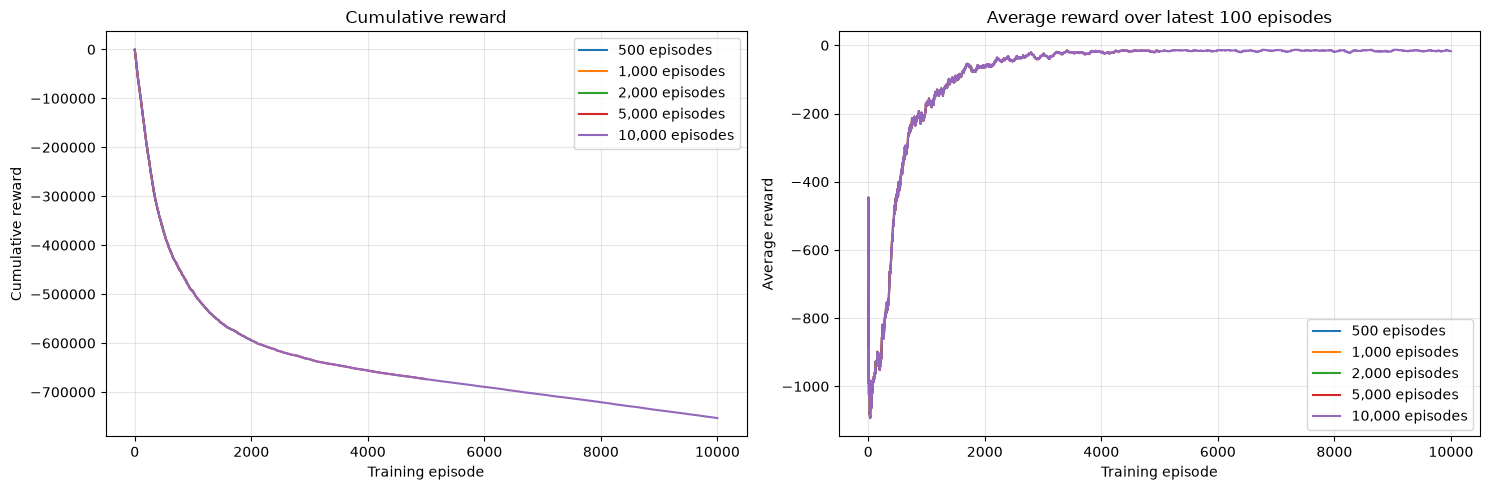

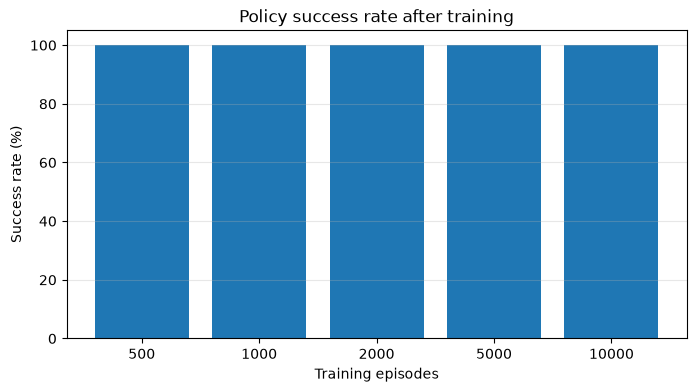

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for episodes, result in results.items():
    rewards = result["rewards"]
    axes[0].plot(np.cumsum(rewards), label=f"{episodes:,} episodes")
    axes[1].plot(pd.Series(rewards).rolling(100, min_periods=1).mean(), label=f"{episodes:,} episodes")
axes[0].set(title="Cumulative reward", xlabel="Training episode", ylabel="Cumulative reward")
axes[1].set(title="Average reward over latest 100 episodes", xlabel="Training episode", ylabel="Average reward")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(summary_df["Training episodes"].astype(str), summary_df["Test success rate (%)"])
plt.title("Policy success rate after training")
plt.xlabel("Training episodes")
plt.ylabel("Success rate (%)")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Environment and extracted policy

The arrows show the greedy action selected by the best-performing Q-table. `S` is the start, `C` marks the cliff, and `G` is the goal.

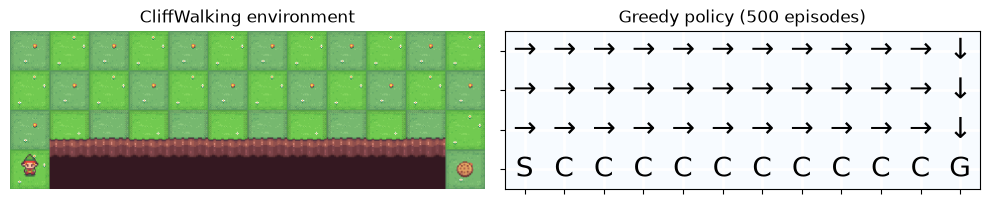

Policy action numbers (0=up, 1=right, 2=down, 3=left):
[[1 1 1 1 1 1 1 1 1 1 1 2]
 [1 1 1 1 1 1 1 1 1 1 1 2]
 [1 1 1 1 1 1 1 1 1 1 1 2]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


In [5]:
best_episodes = int(summary_df.loc[summary_df["Test success rate (%)"].idxmax(), "Training episodes"])
policy = np.argmax(results[best_episodes]["q_table"], axis=1).reshape(4, 12)
symbols = {0: "↑", 1: "→", 2: "↓", 3: "←"}
cliff = np.array([list(row) for row in ["FFFFFFFFFFFF", "FFFFFFFFFFFF", "FFFFFFFFFFFF", "SCCCCCCCCCCG"]])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
env = gym.make("CliffWalking-v1", render_mode="rgb_array")
env.reset(seed=SEED)
axes[0].imshow(env.render())
axes[0].set_title("CliffWalking environment")
axes[0].axis("off")
env.close()

axes[1].imshow(np.zeros((4, 12)), cmap="Blues", vmin=0, vmax=1)
for row in range(4):
    for col in range(12):
        label = cliff[row, col] if cliff[row, col] in "SCG" else symbols[policy[row, col]]
        axes[1].text(col, row, label, ha="center", va="center", fontsize=20)
axes[1].set(xticks=range(12), yticks=range(4), xticklabels=[], yticklabels=[], title=f"Greedy policy ({best_episodes:,} episodes)")
axes[1].grid(color="white", linewidth=2)
plt.tight_layout()
plt.show()
print("Policy action numbers (0=up, 1=right, 2=down, 3=left):")
print(policy)

In [6]:
# Minimal self-check for the tabular experiment.
assert set(summary_df["Training episodes"]) == set(EPISODE_CONFIGS)
assert all(len(result["rewards"]) == episodes for episodes, result in results.items())
assert summary_df["Test success rate (%)"].between(0, 100).all()
print("Lab checks passed.")

Lab checks passed.
